# CUAD Class Imbalance Analysis

Goal: Evaluate how unevenly the 41 CUAD clause categories are represented and identify what that may mean for modeling.

# Imports


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

/Users/j/Accenture-1F-contract-review-challenge/notebooks


In [4]:

train_df = pd.read_pickle("../data/cuad/dataframes/train.pkl")
test_df = pd.read_pickle("../data/cuad/dataframes/test.pkl")
full_df = pd.read_pickle("../data/cuad/dataframes/full.pkl")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Full shape:", full_df.shape)

Train shape: (16728, 10)
Test shape: (4182, 10)
Full shape: (20910, 10)


In [6]:
print(full_df.columns.tolist())
display(full_df.head())

['contract_title', 'category', 'split', 'question', 'qa_id', 'is_impossible', 'num_answers', 'answer_texts', 'answer_starts', 'context_length']


,contract_title,category,split,question,qa_id,is_impossible,num_answers,answer_texts,answer_starts,context_length
0,2ThemartComInc_19990826_10-12G_EX-10.10_670028...,Affiliate License-Licensee,full,Highlight the parts (if any) of this contract ...,2ThemartComInc_19990826_10-12G_EX-10.10_670028...,True,0,[],[],29454
1,2ThemartComInc_19990826_10-12G_EX-10.10_670028...,Affiliate License-Licensor,full,Highlight the parts (if any) of this contract ...,2ThemartComInc_19990826_10-12G_EX-10.10_670028...,True,0,[],[],29454
2,2ThemartComInc_19990826_10-12G_EX-10.10_670028...,Agreement Date,full,Highlight the parts (if any) of this contract ...,2ThemartComInc_19990826_10-12G_EX-10.10_670028...,False,1,"[June 21, 1999]",[114],29454
3,2ThemartComInc_19990826_10-12G_EX-10.10_670028...,Anti-Assignment,full,Highlight the parts (if any) of this contract ...,2ThemartComInc_19990826_10-12G_EX-10.10_670028...,False,2,[All rights (under any applicable intellectual...,"[12261, 12412]",29454
4,2ThemartComInc_19990826_10-12G_EX-10.10_670028...,Audit Rights,full,Highlight the parts (if any) of this contract ...,2ThemartComInc_19990826_10-12G_EX-10.10_670028...,False,3,[Such inspection shall be at 2TheMart's expens...,"[8958, 8593, 8701]",29454


In [7]:
print("Rows:", len(full_df))
print("Unique contracts:", full_df["contract_title"].nunique())
print("Unique categories:", full_df["category"].nunique())

print("\nSplit values:")
print(full_df["split"].value_counts())

Rows: 20910
Unique contracts: 510
Unique categories: 41

Split values:
split
full    20910
Name: count, dtype: int64


In [8]:
check = (
    (full_df["is_impossible"] == False)
    ==
    (full_df["num_answers"] > 0)
)

print("Rows where positive status matches num_answers:", check.sum())
print("Rows where they disagree:", (~check).sum())

Rows where positive status matches num_answers: 20910
Rows where they disagree: 0


In [ ]:
# This table is showing within-label imbalance because each row compares positive vs negative
#  contracts for the same category.
imbalance_df = (
    full_df
    .groupby("category")
    .agg(
        Positive_Contracts=("is_impossible", lambda x: (~x).sum()),
        Negative_Contracts=("is_impossible", "sum")
    )
    .reset_index()
)

imbalance_df["Percent_Positive"] = (
    imbalance_df["Positive_Contracts"]
    /
    (imbalance_df["Positive_Contracts"] + imbalance_df["Negative_Contracts"])
    * 100
).round(1)

imbalance_df = imbalance_df.sort_values(
    "Positive_Contracts",
    ascending=False
)

imbalance_df

,category,Positive_Contracts,Negative_Contracts,Percent_Positive
9,Document Name,510,0,100.0
28,Parties,509,1,99.8
2,Agreement Date,470,40,92.2
13,Governing Law,437,73,85.7
12,Expiration Date,413,97,81.0
10,Effective Date,390,120,76.5
3,Anti-Assignment,374,136,73.3
5,Cap On Liability,275,235,53.9
18,License Grant,255,255,50.0
4,Audit Rights,214,296,42.0


### Observation — Overall label frequency

The percentage of contracts containing each label varies substantially.

Examples:
- Document Name: 100%
- Parties: 99.8%
- Cap On Liability: 53.9%
- Change Of Control: 23.7%
- Source Code Escrow: 2.5%

This shows strong between-label imbalance: some CUAD categories appear in nearly every contract, while others appear in very few.

In [10]:
median_positive = imbalance_df["Positive_Contracts"].median()

most_common = imbalance_df["Positive_Contracts"].max()
least_common = imbalance_df["Positive_Contracts"].min()

imbalance_ratio = most_common / least_common

print("Median positive contracts:", median_positive)
print("Most common positive count:", most_common)
print("Least common positive count:", least_common)
print("Overall positive-frequency imbalance ratio:", round(imbalance_ratio, 2), ": 1")

Median positive contracts: 119.0
Most common positive count: 510
Least common positive count: 13
Overall positive-frequency imbalance ratio: 39.23 : 1


### Observation — Between-Label Imbalance

- The median category appears in 119 of 510 contracts, or about 23% of the dataset.

- This means that if all 41 labels are sorted by frequency, the category in the middle is still absent from most contracts.

- The most common label has 510 positive examples, while the rarest has only 13.

- Overall positive-frequency imbalance ratio of  **39.23:1**.

- The most represented label has about 39 times as many positive contract examples as the least represented label.

In [11]:
imbalance_df["Negative_to_Positive_Ratio"] = (
    imbalance_df["Negative_Contracts"]
    / imbalance_df["Positive_Contracts"]
).round(2)

imbalance_df[
    [
        "category",
        "Positive_Contracts",
        "Negative_Contracts",
        "Percent_Positive",
        "Negative_to_Positive_Ratio"
    ]
].sort_values(
    "Negative_to_Positive_Ratio",
    ascending=False
)

,category,Positive_Contracts,Negative_Contracts,Percent_Positive,Negative_to_Positive_Ratio
34,Source Code Escrow,13,497,2.5,38.23
30,Price Restrictions,15,495,2.9,33.00
38,Unlimited/All-You-Can-Eat-License,17,493,3.3,29.00
1,Affiliate License-Licensor,23,487,4.5,21.17
21,Most Favored Nation,28,482,5.5,17.21
36,Third Party Beneficiary,32,478,6.3,14.94
22,No-Solicit Of Customers,34,476,6.7,14.00
25,Non-Disparagement,38,472,7.5,12.42
17,Joint Ip Ownership,46,464,9.0,10.09
23,No-Solicit Of Employees,59,451,11.6,7.64


### Observation — Within-Label Imbalance

Class imbalance also occurs within individual categories.

Example:

`Source Code Escrow`
- Positive: 13
- Negative: 497
- Positive prevalence: 2.5%
- About 38 negative contracts for every 1 positive contract

By contrast:

`License Grant`
- Positive: 255
- Negative: 255
- Positive prevalence: 50%

`License Grant` is almost perfectly balanced, while `Source Code Escrow` is extremely skewed toward the negative class.

This means some CUAD labels create much harder binary classification problems than others.

In [12]:
def rarity_group(percent):
    if percent > 50:
        return "Very Common"
    elif percent >= 20:
        return "Moderate"
    elif percent >= 5:
        return "Rare"
    else:
        return "Very Rare"

imbalance_df["Rarity_Group"] = (
    imbalance_df["Percent_Positive"].apply(rarity_group)
)

rarity_counts = imbalance_df["Rarity_Group"].value_counts()

rarity_counts

Rarity_Group
Moderate       15
Rare           14
Very Common     8
Very Rare       4
Name: count, dtype: int64

### Analysis Frequency Groups

To summarize positive prevalence, categories were grouped using the following analysis-defined thresholds:

- **Very Common:** >50% of contracts positive
- **Moderate:** 20–50%
- **Rare:** 5–20%
- **Very Rare:** <5%

These are not official CUAD classifications. They are analysis buckets used to make the class distribution easier to interpret.

In [13]:
for group in ["Very Common", "Moderate", "Rare", "Very Rare"]:
    print(f"\n{group}")
    
    group_df = imbalance_df[
        imbalance_df["Rarity_Group"] == group
    ][["category", "Positive_Contracts", "Percent_Positive"]]
    
    display(group_df)


Very Common


,category,Positive_Contracts,Percent_Positive
9,Document Name,510,100.0
28,Parties,509,99.8
2,Agreement Date,470,92.2
13,Governing Law,437,85.7
12,Expiration Date,413,81.0
10,Effective Date,390,76.5
3,Anti-Assignment,374,73.3
5,Cap On Liability,275,53.9



Moderate


,category,Positive_Contracts,Percent_Positive
18,License Grant,255,50.0
4,Audit Rights,214,42.0
35,Termination For Convenience,183,35.9
29,Post-Termination Services,182,35.7
11,Exclusivity,180,35.3
31,Renewal Term,176,34.5
32,Revenue/Profit Sharing,166,32.5
14,Insurance,166,32.5
20,Minimum Commitment,165,32.4
26,Non-Transferable License,138,27.1



Rare


,category,Positive_Contracts,Percent_Positive
8,Covenant Not To Sue,100,19.6
33,Rofr/Rofo/Rofn,85,16.7
39,Volume Restriction,82,16.1
7,Competitive Restriction Exception,76,14.9
40,Warranty Duration,75,14.7
16,Irrevocable Or Perpetual License,70,13.7
19,Liquidated Damages,61,12.0
23,No-Solicit Of Employees,59,11.6
0,Affiliate License-Licensee,59,11.6
17,Joint Ip Ownership,46,9.0



Very Rare


,category,Positive_Contracts,Percent_Positive
1,Affiliate License-Licensor,23,4.5
38,Unlimited/All-You-Can-Eat-License,17,3.3
30,Price Restrictions,15,2.9
34,Source Code Escrow,13,2.5


In [14]:
print("Very Common:",
      (imbalance_df["Rarity_Group"] == "Very Common").sum())

print("Moderate:",
      (imbalance_df["Rarity_Group"] == "Moderate").sum())

print("Rare:",
      (imbalance_df["Rarity_Group"] == "Rare").sum())

print("Very Rare:",
      (imbalance_df["Rarity_Group"] == "Very Rare").sum())

Very Common: 8
Moderate: 15
Rare: 14
Very Rare: 4


### Observation — Distribution Across Frequency Groups

Using these analysis thresholds:

- 8 labels are Very Common
- 15 labels are Moderate
- 14 labels are Rare
- 4 labels are Very Rare

This means **18 of the 41 CUAD categories are classified as Rare or Very Rare** in this analysis.

A substantial portion of the label space therefore has relatively limited positive representation.

In [16]:
very_rare_df = imbalance_df[
    imbalance_df["Rarity_Group"] == "Very Rare"
][
    [
        "category",
        "Positive_Contracts",
        "Negative_Contracts",
        "Percent_Positive",
        "Negative_to_Positive_Ratio"
    ]
].sort_values("Positive_Contracts")

very_rare_df

,category,Positive_Contracts,Negative_Contracts,Percent_Positive,Negative_to_Positive_Ratio
34,Source Code Escrow,13,497,2.5,38.23
30,Price Restrictions,15,495,2.9,33.00
38,Unlimited/All-You-Can-Eat-License,17,493,3.3,29.00
1,Affiliate License-Licensor,23,487,4.5,21.17


### Observation — Most Severely Imbalanced Categories

The four Very Rare categories are:

- `Affiliate License-Licensor`: 23 positive / 487 negative
- `Unlimited/All-You-Can-Eat-License`: 17 / 493
- `Price Restrictions`: 15 / 495
- `Source Code Escrow`: 13 / 497

These labels may be especially difficult for a model to learn because very few positive examples are available compared with the number of negatives.

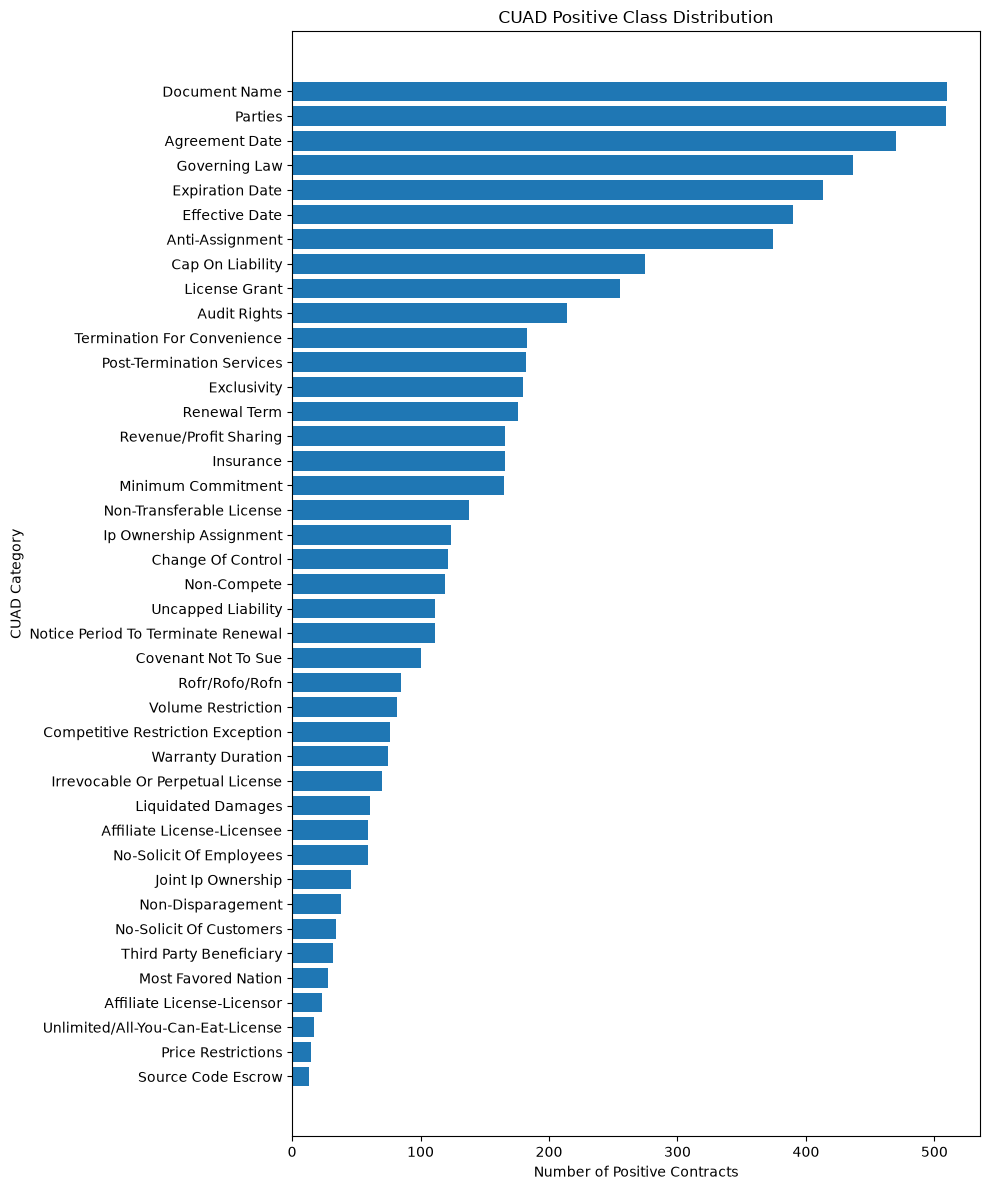

In [17]:
plot_df = imbalance_df.sort_values(
    "Positive_Contracts",
    ascending=True
)

plt.figure(figsize=(10, 12))

plt.barh(
    plot_df["category"],
    plot_df["Positive_Contracts"]
)

plt.xlabel("Number of Positive Contracts")
plt.ylabel("CUAD Category")
plt.title("CUAD Positive Class Distribution")
plt.tight_layout()

plt.show()

## Overall Observations

The class imbalance observed in CUAD has several implications for modeling.

For rare categories, a model could obtain deceptively high accuracy simply by predicting that the clause is absent.

For example, `Source Code Escrow` appears in only 13 of 510 contracts. A model that predicted "absent" for every contract would be correct for 497 of 510 contracts (~97.5%) while failing to detect every actual positive example.

Therefore, overall accuracy alone would not adequately measure performance.

Evaluation should emphasize per-category:

- **Recall:** Of the real positive examples, how many did the model identify?
- **Precision:** When the model predicts a category, how often is it correct?
- **F1:** A balance between precision and recall.

Per-category metrics are important because aggregate scores may hide poor performance on rare labels.

Possible approaches to investigate later include:
- class weighting
- oversampling rare positive examples
- per-category threshold tuning
- selecting an initial subset of sufficiently represented and business-relevant categories

The next analysis should examine how these positive examples are distributed between the official training and test splits.